In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Read DataSet

In [2]:
df = pd.read_csv(r"C:\Users\ryana\Downloads\DataSet\housing.csv")
pd.set_option('display.max_columns', None)

In [3]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


### Data Summary

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [7]:
df.shape

(20640, 10)

## Cleaning Data

### Handling Missing-Value

In [8]:
# Using Median Technique
median_bedrooms = (df['total_bedrooms'].mean()).round(4)
print(median_bedrooms)

537.8706


In [10]:
# Imputation null value with Median Value
df['total_bedrooms'].fillna(median_bedrooms, inplace=True)
# df.method({'total_bedrooms': median_bedrooms}, inplace=True)

C:\Users\ryana\AppData\Local\Temp\ipykernel_18300\289751519.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(median_bedrooms, inplace=True)


In [11]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

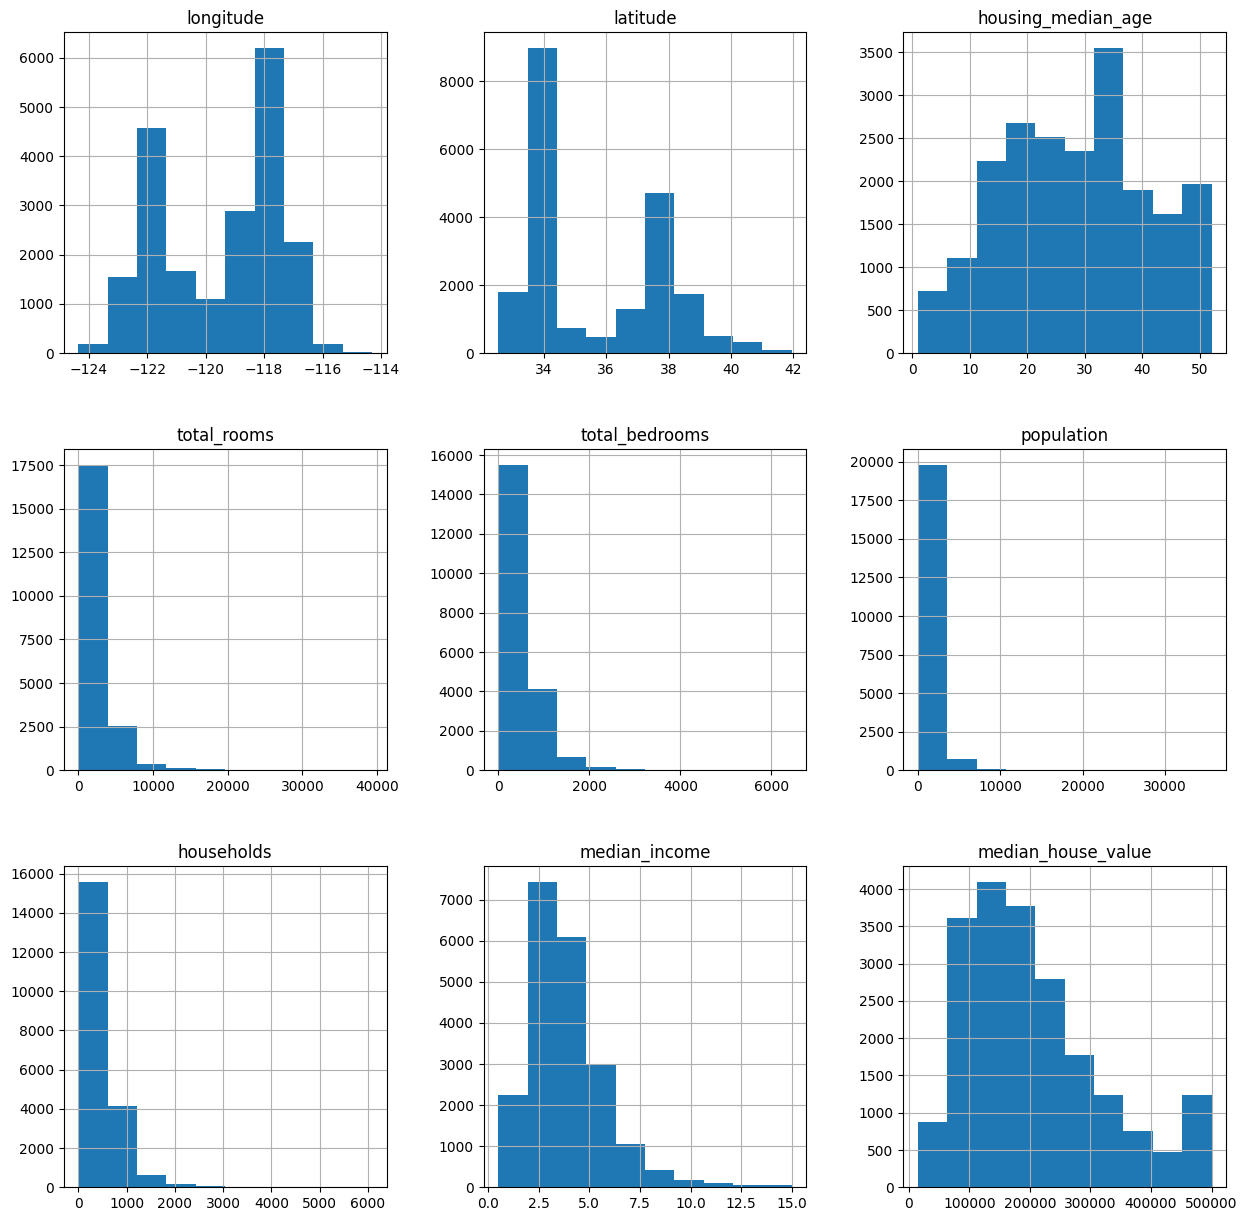

In [12]:
df.hist(figsize=(15,15))

## Outlier Analysis

In [13]:
df_model = df.copy()

In [14]:
df_model.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14062,-117.12,32.74,52.0,1969.0,389.0,877.0,424.0,3.7900,163400.0,NEAR OCEAN
17237,-119.66,34.43,27.0,5509.0,1059.0,2591.0,979.0,3.8456,500001.0,<1H OCEAN
11851,-120.53,39.79,18.0,1234.0,266.0,543.0,201.0,2.5156,71900.0,INLAND
7156,-118.15,34.04,44.0,647.0,142.0,457.0,143.0,3.6875,162500.0,<1H OCEAN
4261,-118.34,34.10,28.0,2223.0,752.0,1271.0,684.0,2.5434,232100.0,<1H OCEAN


### BoxPLot

In [15]:
numeric_col = df_model.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_col.remove('median_house_value')
print(numeric_col)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']


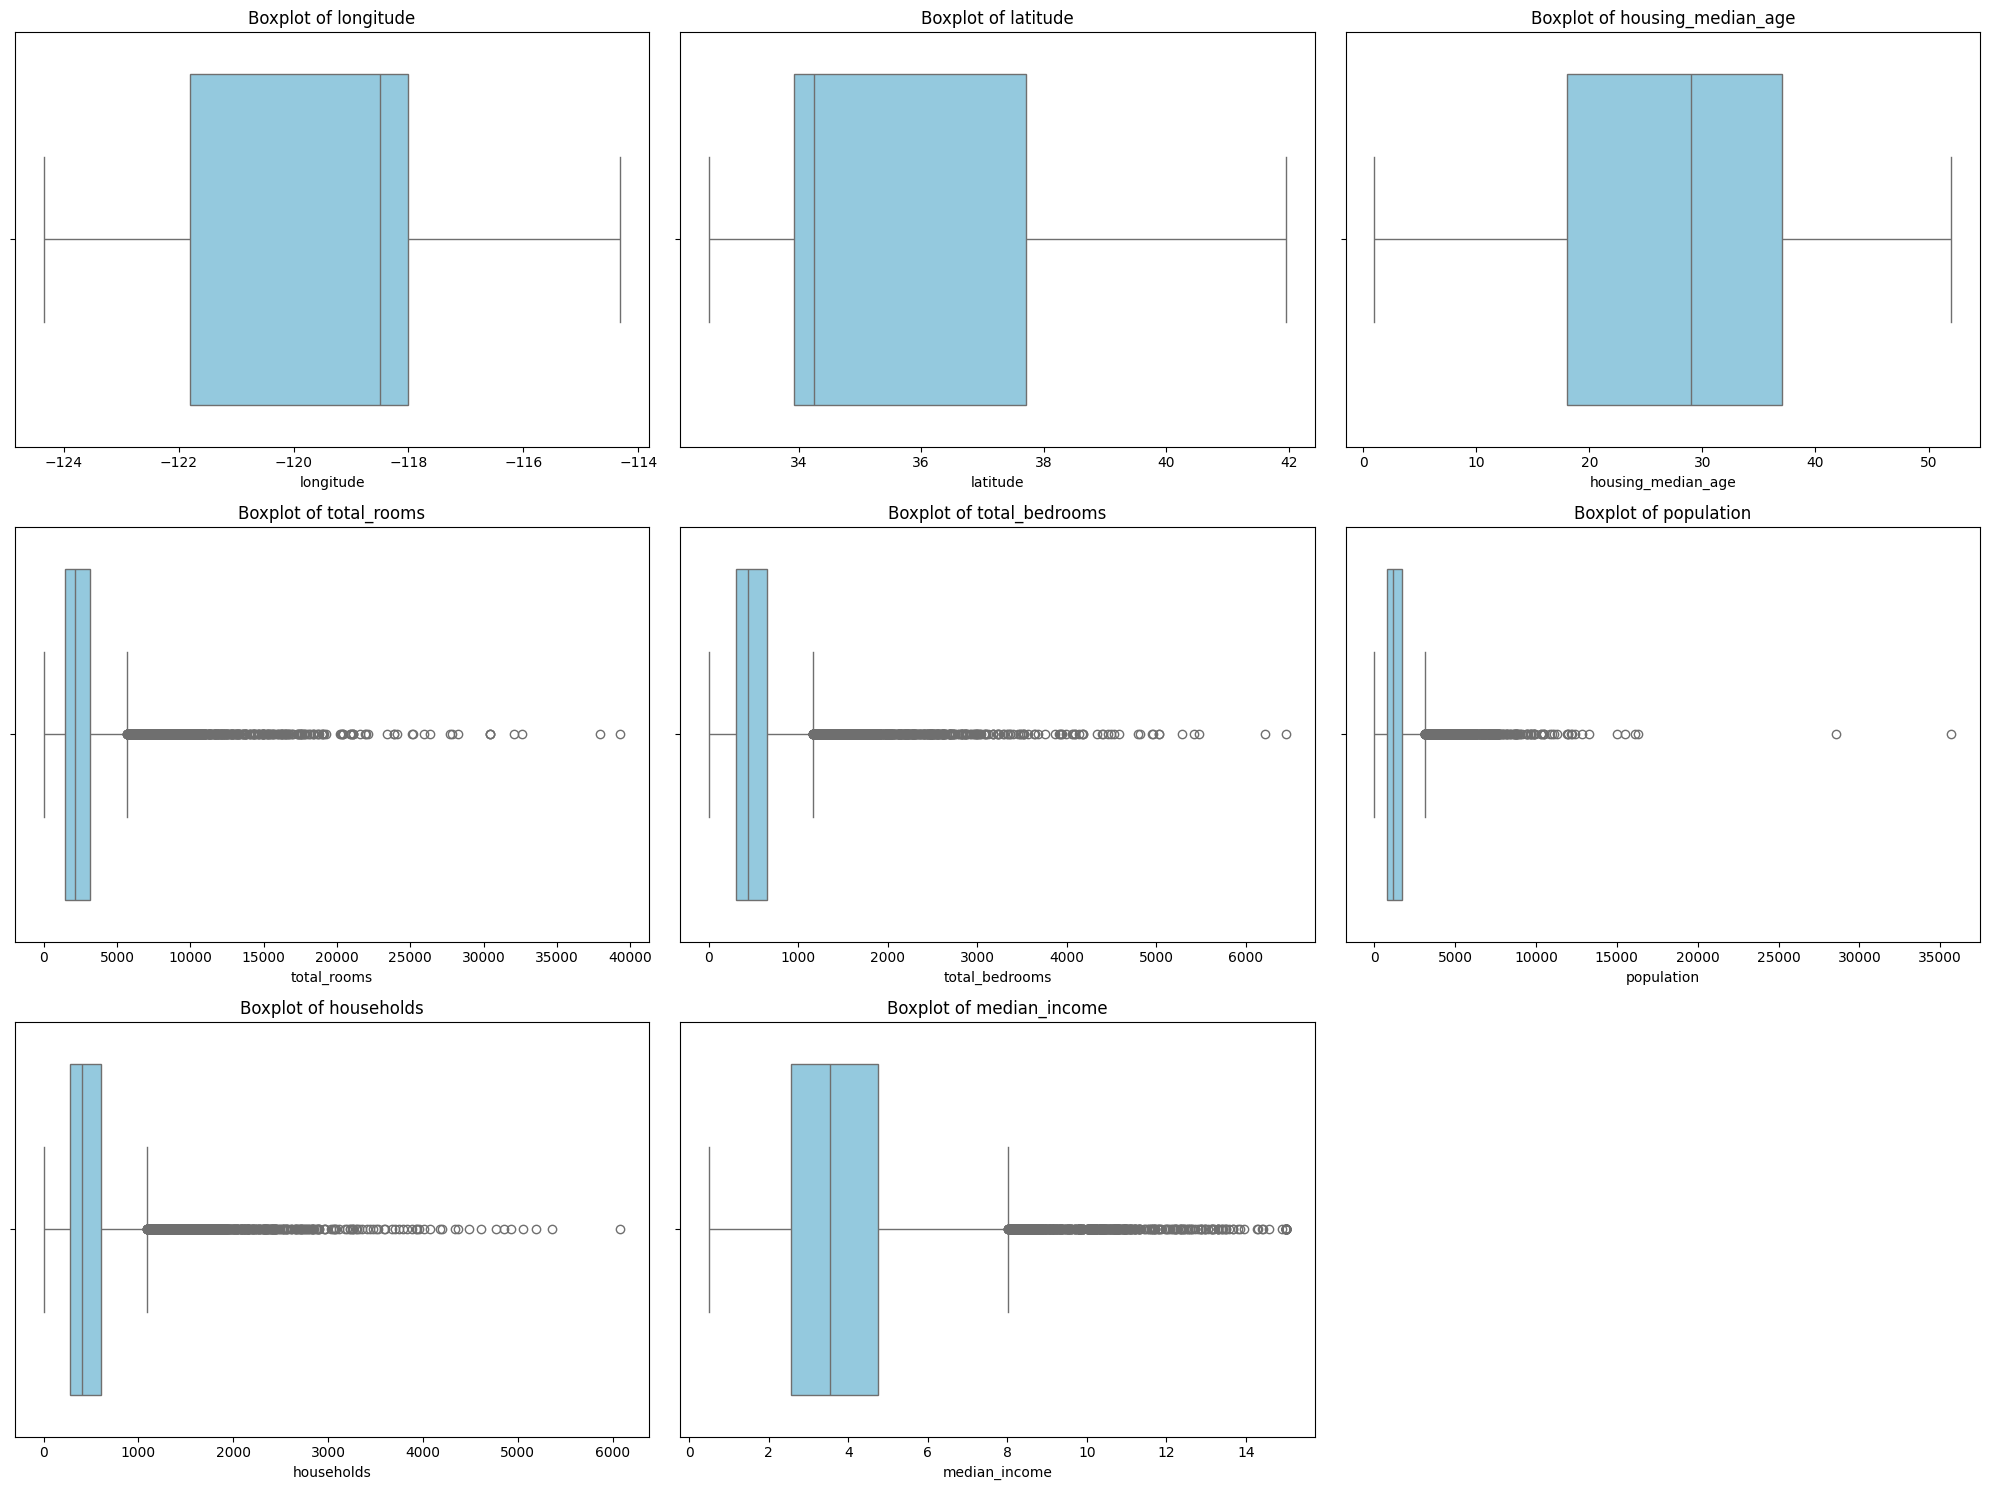

In [17]:
plt.figure(figsize=(20,15))
for i, col in enumerate(numeric_col):
    plt.subplot(3,3, i+1)
    sns.boxplot(x=df_model[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### Z-Score Method

In [18]:
from scipy.stats import zscore

In [19]:
z_score = np.abs(zscore(df_model[numeric_col]))

#take a row which contain zscore > 3
outlier_rows = (z_score > 3).any(axis=1)
print(f"Jumlah baris yang mengandung outlier (Z-score > 3): {outlier_rows.sum()}")

Jumlah baris yang mengandung outlier (Z-score > 3): 894


In [20]:
df_model

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [21]:
z_score

array([[1.32783522, 1.05254828, 0.98214266, ..., 0.9744286 , 0.97703285,
        2.34476576],
       [1.32284391, 1.04318455, 0.60701891, ..., 0.86143887, 1.66996103,
        2.33223796],
       [1.33282653, 1.03850269, 1.85618152, ..., 0.82077735, 0.84363692,
        1.7826994 ],
       ...,
       [0.8237132 , 1.77823747, 0.92485123, ..., 0.3695372 , 0.17404163,
        1.14259331],
       [0.87362627, 1.77823747, 0.84539315, ..., 0.60442933, 0.39375258,
        1.05458292],
       [0.83369581, 1.75014627, 1.00430931, ..., 0.03397701, 0.07967221,
        0.78012947]], shape=(20640, 8))

### IQR Method (Interquartile Range)

In [22]:
Q1 = df_model[numeric_col].quantile(0.25)
Q3 = df_model[numeric_col].quantile(0.75)
IQR = Q3 - Q1

In [23]:
# Kondisi outlier: data < Q1 - 1.5*IQR atau > Q3 + 1.5*IQR
outlier_condition = ((df_model[numeric_col] < (Q1 - 1.5 * IQR)) |
                     (df_model[numeric_col] > (Q3 + 1.5 * IQR)))

In [24]:
# Hitung jumlah baris dengan minimal 1 outlier
outliers_iqr = outlier_condition.any(axis=1)
print(f"Jumlah baris yang mengandung outlier (IQR method): {outliers_iqr.sum()}")

Jumlah baris yang mengandung outlier (IQR method): 2468


### Cleaning Outlier with IQR

In [25]:
# Buat kondisi boolean: True jika baris valid (tidak outlier di semua fitur numerik)
condition = ~((df_model[numeric_col] < (Q1 - 1.5 * IQR)) |
              (df_model[numeric_col] > (Q3 + 1.5 * IQR))).any(axis=1)

In [26]:
# Terapkan filter
df_model_clean = df_model[condition].copy()

In [27]:
print(f'Jumlah data sebelum menghapus outlier: {df_model.shape[0]}')
print(f'Jumlah data setelah menghapus outlier: {df_model_clean.shape[0]}')

Jumlah data sebelum menghapus outlier: 20640
Jumlah data setelah menghapus outlier: 18172


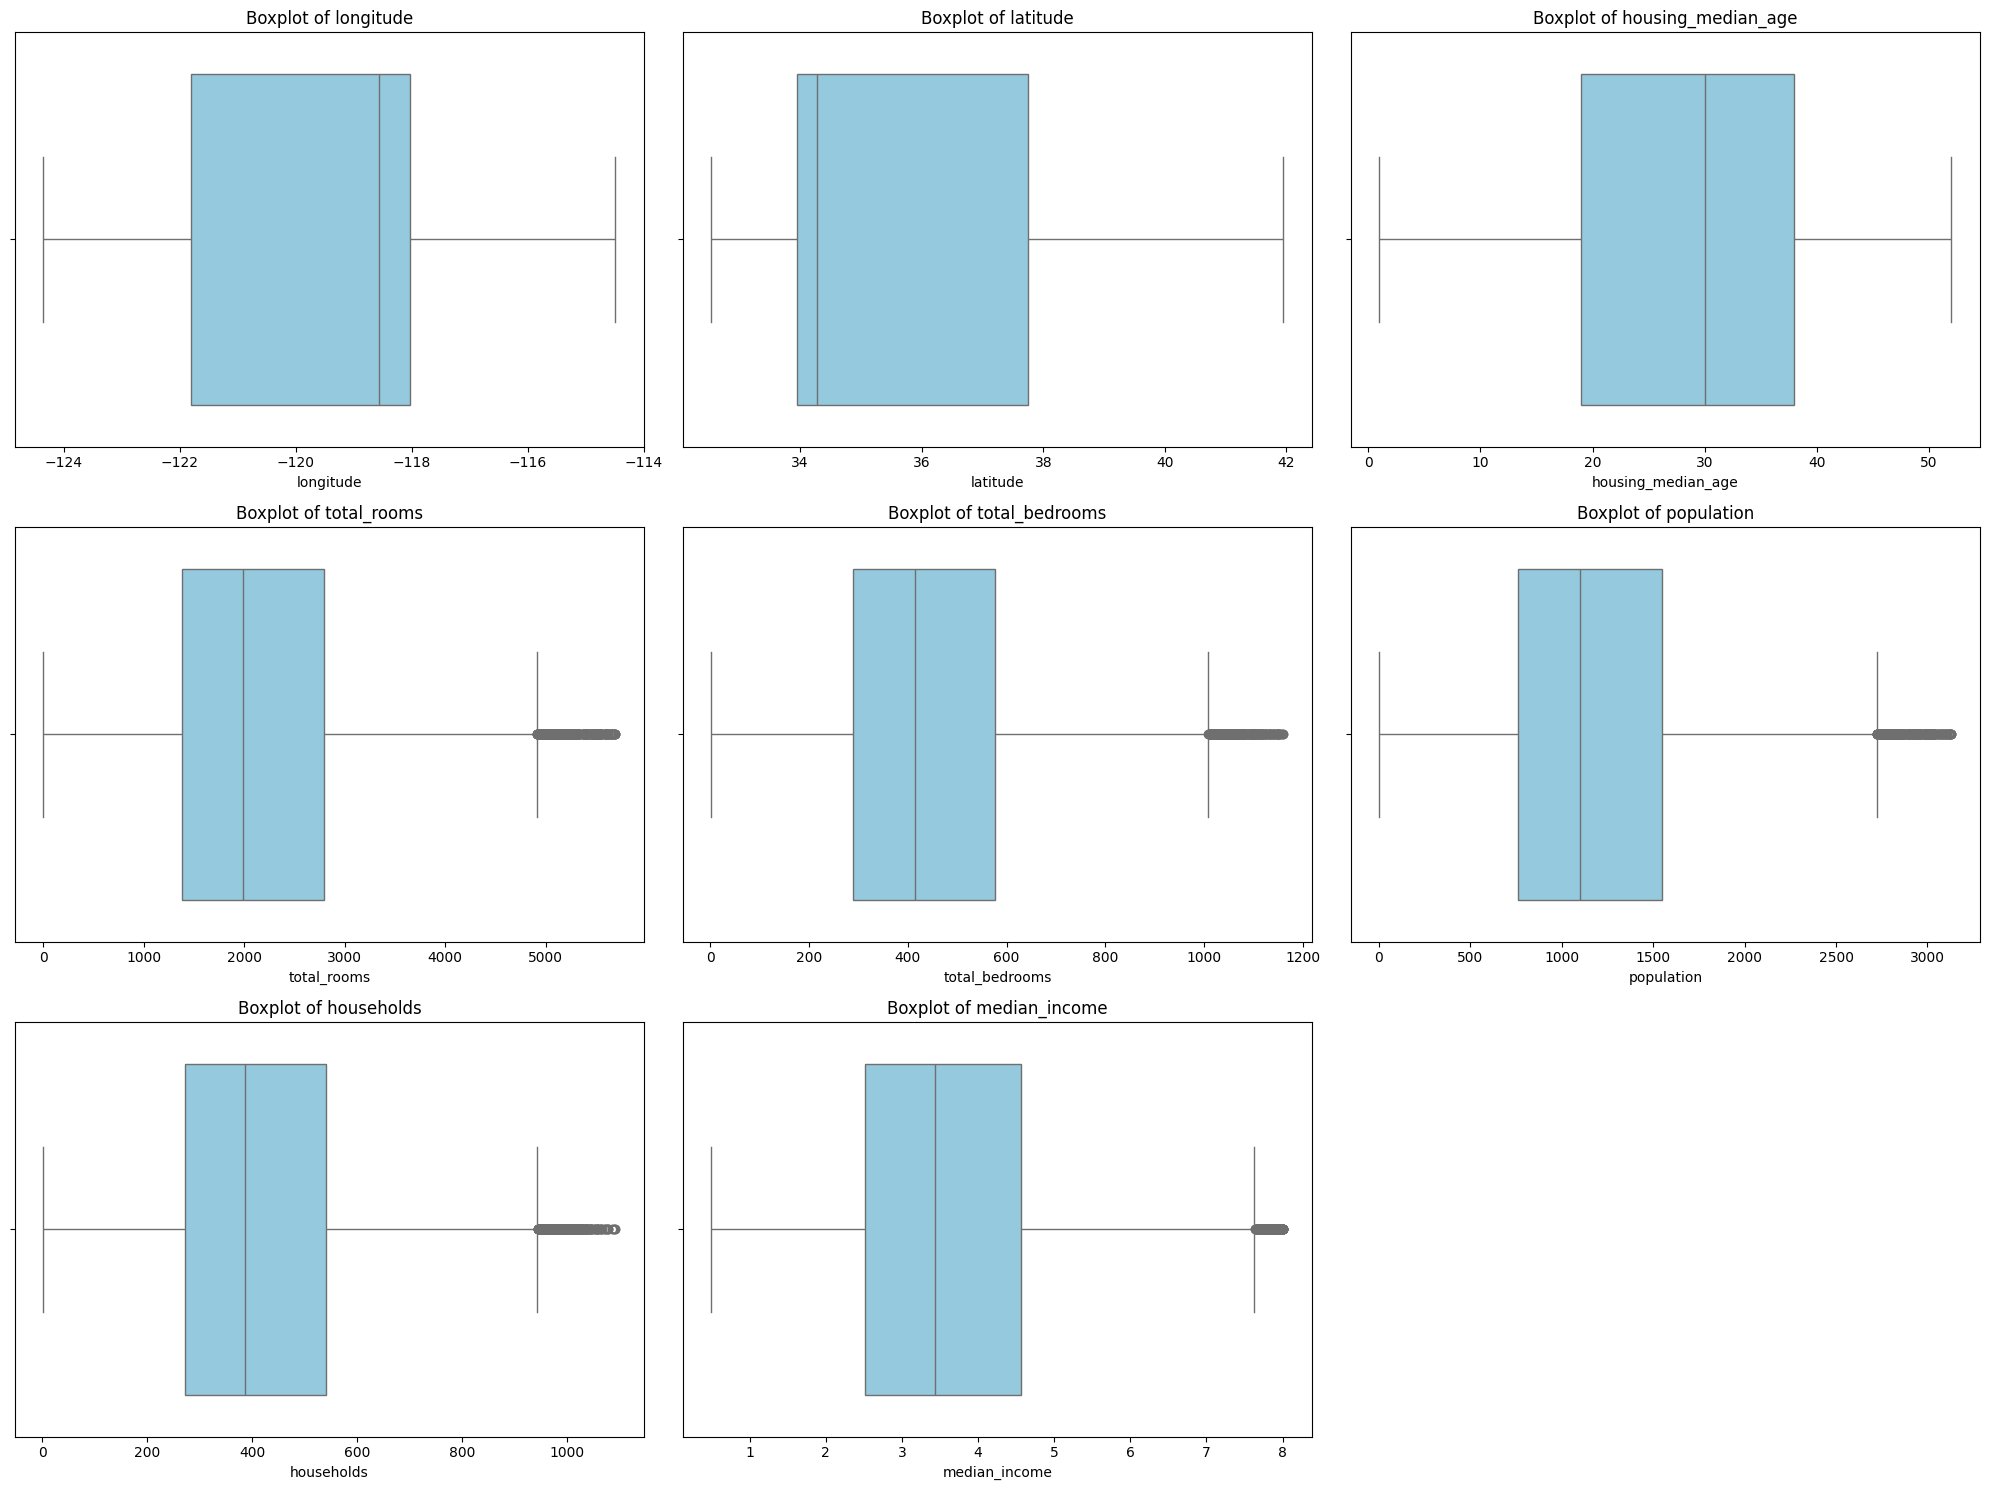

In [28]:
plt.figure(figsize=(20,15))
for i, col in enumerate(numeric_col):
    plt.subplot(3,3, i+1)
    sns.boxplot(x=df_model_clean[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [29]:
df_model_clean.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
5837,-118.34,34.19,41.0,1524.0,393.0,1176.0,375.0,2.8750,192400.0,<1H OCEAN
14064,-117.12,32.75,15.0,2671.0,724.0,1800.0,646.0,2.1394,106700.0,NEAR OCEAN
9288,-122.41,38.07,20.0,4536.0,708.0,1812.0,701.0,6.0433,435900.0,NEAR BAY
6373,-118.02,34.15,44.0,2419.0,437.0,1045.0,432.0,3.8750,280800.0,INLAND
13631,-117.33,34.07,32.0,2086.0,458.0,1355.0,412.0,2.5238,89200.0,INLAND


## Encoding Column

In [30]:
df_model_clean['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     7899
INLAND        5884
NEAR OCEAN    2357
NEAR BAY      2027
ISLAND           5
Name: count, dtype: int64

#### 🔍 Mana yang Lebih Cocok: One-Hot vs Label Encoding?

| Metode               | Cocok Jika                               | Catatan                                         |
| -------------------- | ---------------------------------------- | ----------------------------------------------- |
| **One-Hot Encoding** | Kategori tidak memiliki urutan (nominal) | ✅ Cocok untuk `ocean_proximity`                 |
| Label Encoding       | Kategori punya urutan                    | ❌ Tidak cocok, bisa memberi makna numerik palsu |

👉 Jadi, One-Hot Encoding adalah metode yang paling cocok untuk ocean_proximity.

#### Implementation

In [31]:
# df_model = pd.get_dummies(df_model_clean, columns=['ocean_proximity'], drop_first=True)
df_model_encoded = pd.get_dummies(df_model_clean, columns=['ocean_proximity'], drop_first=True)

In [32]:
df_model

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## Scaling Feature

### Introduction

🔍 Kenapa Feature Scaling Penting?
Model seperti:
- K-Nearest Neighbors (KNN)
- Logistic Regression
- SVM
- Gradient Descent-based Models (Linear/Logistic Regression, Neural Nets)  
akan terpengaruh oleh skala dari fitur numerik. Jadi scaling penting agar semua fitur memiliki pengaruh yang seimbang.

✅ Metode Scaling yang Umum
| Metode             | Deskripsi              | Library                         |
| ------------------ | ---------------------- | ------------------------------- |
| **StandardScaler** | Mean = 0, Std Dev = 1  | Cocok jika distribusi normal    |
| **MinMaxScaler**   | Skala 0–1              | Cocok jika data tidak normal    |
| **RobustScaler**   | Gunakan median dan IQR | Cocok untuk data dengan outlier |

👉 Karena kita sudah hapus outlier, maka StandardScaler adalah pilihan yang optimal.

### ✅ Implementasi with StandardScaler

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
# Pisahkan fitur numerik asli (tanpa target dan dummy variable)
# feature_cols = df_model.drop('median_house_value', axis=1).columns.tolist()
feature_cols = df_model_encoded.drop('median_house_value', axis=1).columns.tolist()

In [36]:
# df_model_encoded adalah hasil akhir setelah encoding
# Drop target untuk ambil semua fitur
X = df_model_encoded.drop('median_house_value', axis=1)
y = df_model_encoded['median_house_value']

In [37]:
# Pilih kolom numerik (tidak termasuk kolom hasil one-hot encoding, karena itu boolean/integer 0/1)
numerical_cols = df_model_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('median_house_value')  # target tidak disertakan

In [38]:
# Scaling hanya fitur numerik
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

In [39]:
X[numerical_cols].describe().T[['mean', 'std']]

,mean,std
longitude,4.104037e-15,1.000028
latitude,-7.382262e-16,1.000028
housing_median_age,-2.502462e-17,1.000028
total_rooms,3.753693e-17,1.000028
total_bedrooms,-2.252216e-16,1.000028
population,-1.438916e-16,1.000028
households,-3.128077e-17,1.000028
median_income,5.004924e-17,1.000028


In [40]:
print("Semua fitur:", X.columns.tolist())
print("Fitur numerik:", numerical_cols)

Semua fitur: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Fitur numerik: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']


## Train-Test Split

### 1. Import dan Split Data

In [41]:
from sklearn.model_selection import train_test_split

# X = fitur, y = target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% data untuk test
    random_state=42,      # agar hasil konsisten
)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (14537, 12), Test set: (3635, 12)


In [46]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
1423,-1.220087,1.075167,-1.116920,-0.977614,-1.041981,-1.387490,-0.899607,-0.865962,False,False,True,False
12475,-0.935628,1.343881,1.815830,-1.444634,-1.364294,-1.525770,-1.410771,-1.092279,True,False,False,False
9162,0.561524,-0.583452,-0.709593,-0.711531,-0.851317,-0.767731,-0.773034,0.931646,False,False,False,False
594,-1.235058,0.940809,0.675316,-0.447284,-0.687890,-0.679432,-0.563700,0.955409,False,False,True,False
11269,0.801068,-0.875332,-0.953989,1.402449,1.123419,1.051562,1.145047,0.013791,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
12846,-0.880732,1.390212,0.512386,-0.344521,-0.683351,-0.419533,-0.544227,-0.305623,True,False,False,False
13652,1.135432,-0.759506,-0.953989,-0.287634,-0.265705,-0.769397,-0.393312,-0.749842,True,False,False,False
6039,0.935812,-0.745607,0.267990,-1.032665,-0.842237,-0.557813,-0.719483,-0.924258,True,False,False,False
937,-1.210106,0.862048,0.430920,-0.260108,-0.469988,0.040288,-0.383576,0.800245,False,False,True,False


In [47]:
X_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
8160,0.736192,-0.866066,0.593851,-0.846407,-0.951188,-1.027630,-0.850925,0.466088,False,False,False,False
19601,-0.686103,0.875947,-0.220802,-1.124418,-1.228105,-1.232551,-1.211174,-0.667784,True,False,False,False
5405,0.581486,-0.764139,0.593851,-1.078541,-1.169090,-1.165910,-1.045654,0.411158,False,False,False,False
1075,-1.105305,1.885944,0.593851,0.078459,-0.338339,-0.357890,-0.183978,-0.290141,True,False,False,False
4703,0.631391,-0.750240,1.815830,-0.767500,-1.255343,-0.932667,-0.987236,2.379143,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
3037,0.242132,-0.138683,-0.953989,-0.577572,-0.805920,-0.804384,-0.670801,0.529769,True,False,False,False
6224,0.836002,-0.754873,0.512386,-0.743644,-1.023822,-0.567809,-0.841189,0.363835,False,False,False,False
18072,-1.195134,0.741590,0.430920,0.901480,0.428857,0.433469,0.672829,1.411542,False,False,False,False
7286,0.681296,-0.787304,1.245573,-1.814397,-1.836415,-1.597409,-1.751547,-0.377113,False,False,False,False


In [48]:
y_train

1423      75000.0
12475     94300.0
9162     229000.0
594      227000.0
11269    143500.0
           ...   
12846     83400.0
13652    116700.0
6039     119400.0
937      186000.0
17961    335900.0
Name: median_house_value, Length: 14537, dtype: float64

In [49]:
y_test

8160     223900.0
19601    129700.0
5405     331000.0
1075      97000.0
4703     500001.0
           ...   
3037     121000.0
6224     205100.0
18072    346100.0
7286     110700.0
3714     191300.0
Name: median_house_value, Length: 3635, dtype: float64

## BaseLine Model

### 1. Train Data

In [42]:
from sklearn.linear_model import LinearRegression

# Inisialisasi model
lr_model = LinearRegression()

# Latih model pada data training
lr_model.fit(X_train, y_train)

LinearRegression()

### 2. Evaluasi Model pada Data Test

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [44]:
# Prediksi pada data test
y_pred = lr_model.predict(X_test)

# Evaluasi performa
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [45]:
print(f"Baseline Model Performance (Linear Regression):")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.4f}")

Baseline Model Performance (Linear Regression):
MAE  : 48854.866
RMSE : 66993.034
R²   : 0.6060


### 3. Interpretasi Koefisien (Opsional)

In [50]:
coefficients = pd.Series(lr_model.coef_, index=X_train.columns)
print(coefficients.sort_values(ascending=False))

ocean_proximity_ISLAND        199128.664608
median_income                  66193.021282
total_bedrooms                 40508.884120
households                     27089.308939
housing_median_age             14712.186244
ocean_proximity_NEAR OCEAN      -238.202410
ocean_proximity_NEAR BAY       -8388.706694
total_rooms                   -20771.340110
ocean_proximity_INLAND        -35102.146949
population                    -45334.570496
longitude                     -50787.435530
latitude                      -53109.681755
dtype: float64


## 🌲 Random Forest Regressor

In [51]:
from sklearn.ensemble import RandomForestRegressor

# Inisialisasi model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

In [52]:
# Latih model
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

In [53]:
# Evaluasi
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [60]:
print("Random Forest Performance:")
print(f"MSE  : {mse_rf:.3f}")
print(f"MAE  : {mae_rf:.3f}")
print(f"RMSE : {rmse_rf:.3f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance:
MSE  : 2584140772.469
MAE  : 32665.333
RMSE : 50834.445
R²   : 0.7732


## 🔥 Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor

# Inisialisasi model
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

In [56]:
# Latih model
gb_model.fit(X_train, y_train)

# Prediksi
y_pred_gb = gb_model.predict(X_test)

In [57]:
# Evaluasi
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

In [59]:
print("Gradient Boosting Performance:")
print(f"MSE  : {mse_gb:.3f}")
print(f"MAE  : {mae_gb:.3f}")
print(f"RMSE : {rmse_gb:.3f}")
print(f"R²   : {r2_gb:.4f}")

Gradient Boosting Performance:
MSE  : 3195227297.786
MAE  : 39061.957
RMSE : 56526.342
R²   : 0.7195


## Comparison Model (Actual vs Predict)

### Create DF

In [63]:
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Linear Regression': y_pred,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}).reset_index(drop=True)

In [64]:
comparison_df.sample(10)

,Actual,Linear Regression,Random Forest,Gradient Boosting
149,98700.0,100870.124016,111040.00,106049.893409
1073,263800.0,309352.982136,297460.00,314152.775359
485,157500.0,207385.996992,170871.00,183352.263763
45,168300.0,215722.426640,169746.00,173796.592662
3167,155400.0,222901.113292,227295.00,214289.492523
172,81300.0,44377.349450,64419.00,87817.559810
369,220200.0,195604.232104,230916.00,210438.238800
86,78900.0,99298.327285,93236.00,100701.268559
177,163000.0,236224.212382,203679.03,224624.304527
1349,60900.0,105825.707200,81286.00,78567.927775


### 📊 Visualisasi Scatter Plot

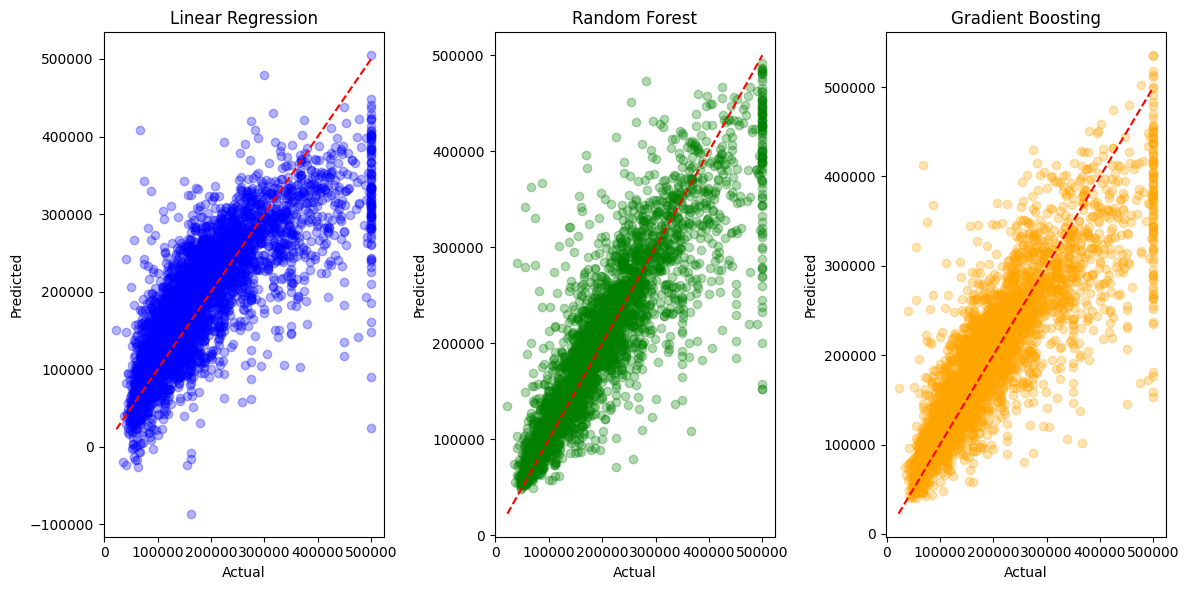

In [62]:
plt.figure(figsize=(12, 6))

# Linear Regression
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title('Linear Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')

# Random Forest
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title('Random Forest')
plt.xlabel('Actual')
plt.ylabel('Predicted')

# Gradient Boosting
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_gb, alpha=0.3, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title('Gradient Boosting')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

### Error Distribution

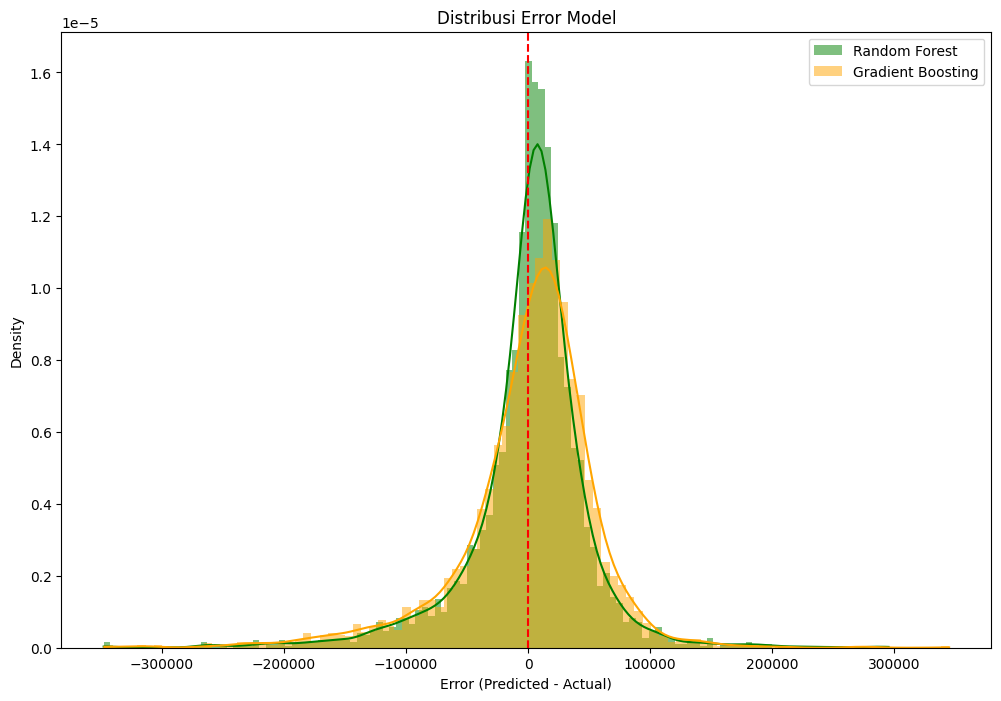

In [66]:
comparison_df['Error_RF'] = comparison_df['Random Forest'] - comparison_df['Actual']
comparison_df['Error_GB'] = comparison_df['Gradient Boosting'] - comparison_df['Actual']

plt.figure(figsize=(12, 8))
sns.histplot(comparison_df['Error_RF'], kde=True, color='green', label='Random Forest', stat="density", linewidth=0)
sns.histplot(comparison_df['Error_GB'], kde=True, color='orange', label='Gradient Boosting', stat="density", linewidth=0)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribusi Error Model")
plt.xlabel("Error (Predicted - Actual)")
plt.legend()
plt.show()

<Axes: >

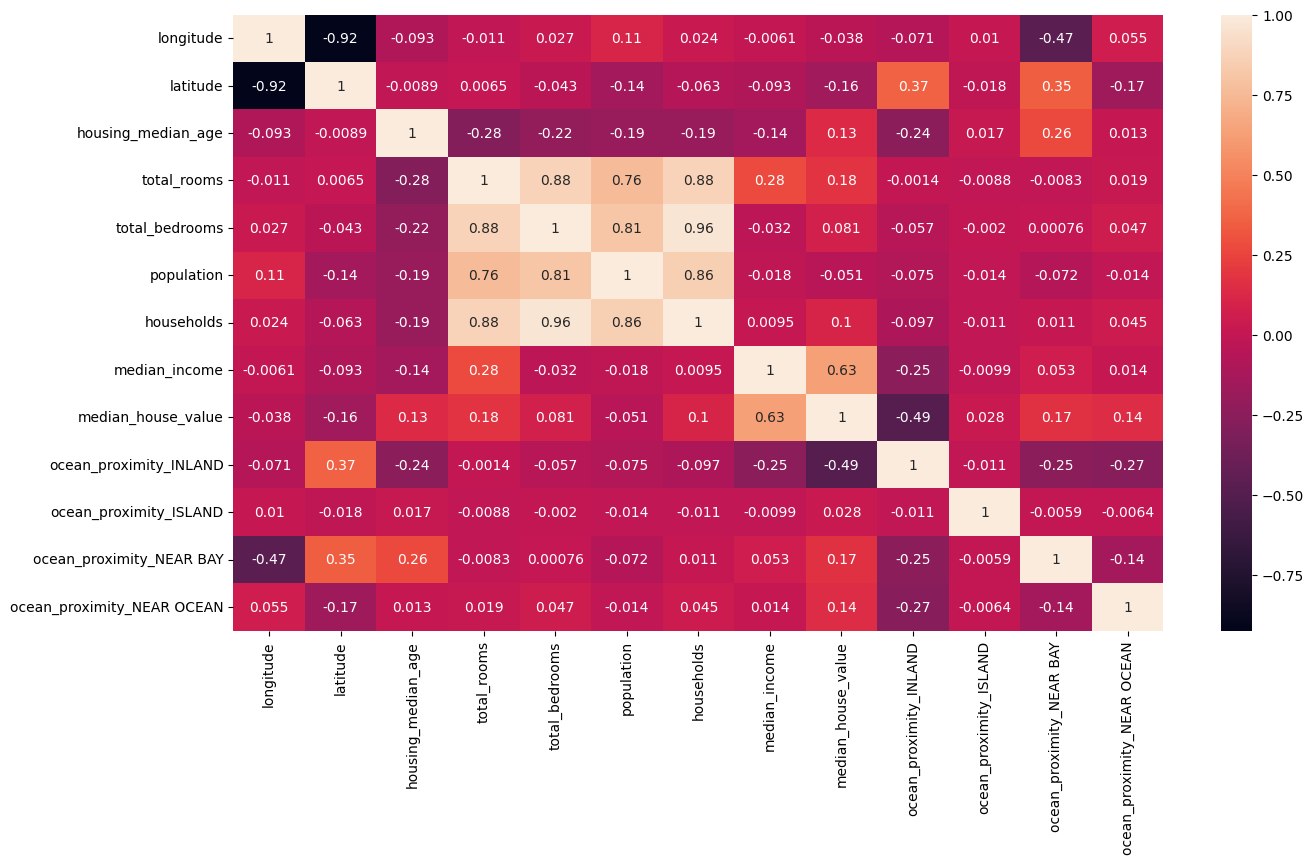

In [67]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_model_encoded.corr(), annot=True)